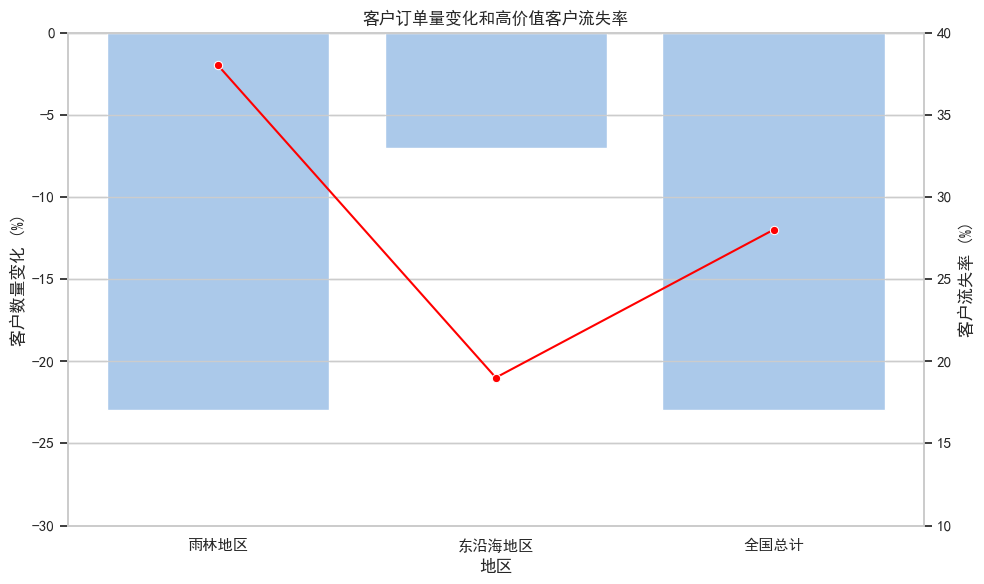

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 显示中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建数据
data = {
    '地区': ['雨林地区', '东沿海地区', '全国总计'],
    '客户数量变化': [-23, -7, -23],
    '客户流失率': [38, 19, 28],
}

# 转换为DataFrame
df = pd.DataFrame(data)

# 将数据导出到Excel文件
df.to_excel('客户数据.xlsx', index=False)

# 创建一个子图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 客户数量变化的柱状图
sns.barplot(x='地区', y='客户数量变化', data=df, ax=ax1)
ax1.set_title('客户订单量变化和高价值客户流失率')
ax1.set_ylabel('客户数量变化 (%)')
ax1.set_ylim(-30, 0)
ax1.set_xlabel('地区')

# 创建第二个y轴
ax2 = ax1.twinx()

# 客户流失率的折线图
sns.lineplot(x='地区', y='客户流失率', marker='o', data=df, ax=ax2, color='red')
ax2.set_ylabel('客户流失率 (%)')
ax2.set_ylim(10, 40)

# 显示图表
plt.tight_layout()
plt.show()


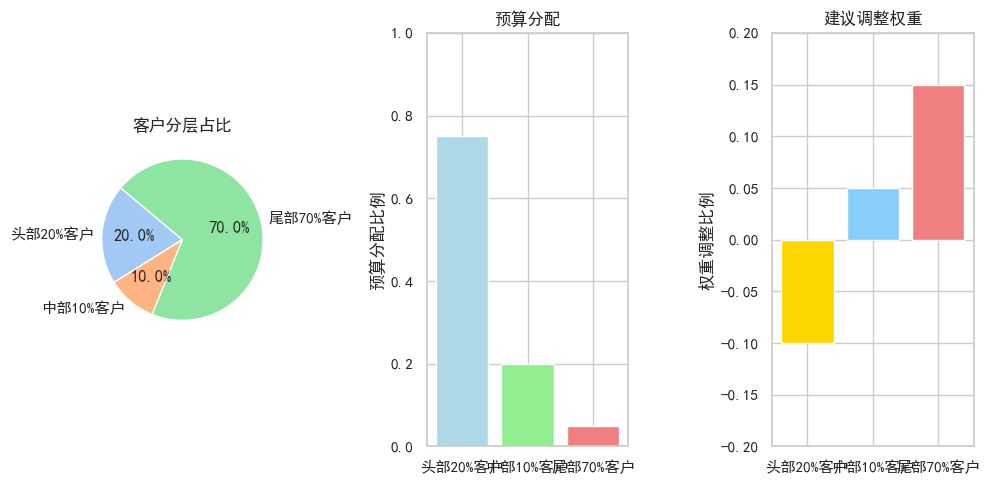

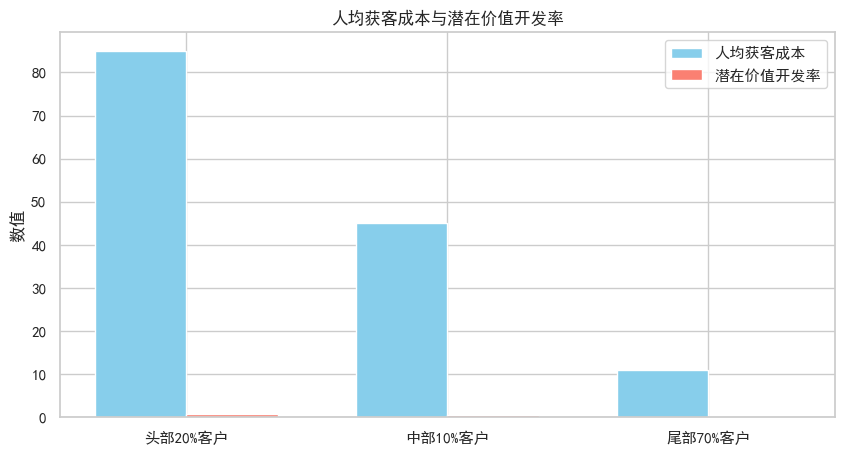

In [9]:
import matplotlib.pyplot as plt

# 客户分层数据
客户层次 = ['头部20%客户', '中部10%客户', '尾部70%客户']
占比 = [0.20, 0.10, 0.70]
预算分配 = [0.75, 0.20, 0.05]
人均获客成本 = [85, 45, 11]
潜在价值开发率 = [0.92, 0.65, 0.28]
建议调整权重 = [-0.10, 0.05, 0.15]

# 创建占比饼图
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.pie(占比, labels=客户层次, autopct='%1.1f%%', startangle=140)
plt.title('客户分层占比')

# 创建预算分配条形图
plt.subplot(1, 3, 2)
plt.bar(客户层次, 预算分配, color=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('预算分配')
plt.ylim(0, 1)  # 设置y轴范围为0到1
plt.ylabel('预算分配比例')

# 创建建议调整权重条形图
plt.subplot(1, 3, 3)
plt.bar(客户层次, 建议调整权重, color=['gold', 'lightskyblue', 'lightcoral'])
plt.title('建议调整权重')
plt.ylim(-0.2, 0.2)  # 设置y轴范围为-0.2到0.2
plt.ylabel('权重调整比例')

plt.tight_layout()
plt.show()

# 人均获客成本和潜在价值开发率的条形图
plt.figure(figsize=(10, 5))
width = 0.35  # 条形的宽度

# 绘制人均获客成本
plt.bar([x - width/2 for x in range(len(客户层次))], 人均获客成本, width, label='人均获客成本', color='skyblue')
# 绘制潜在价值开发率
plt.bar([x + width/2 for x in range(len(客户层次))], 潜在价值开发率, width, label='潜在价值开发率', color='salmon')
plt.title('人均获客成本与潜在价值开发率')
plt.xticks(range(len(客户层次)), 客户层次)
plt.ylabel('数值')
plt.legend()

plt.show()


In [16]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.chart import PieChart, BarChart, Reference
from openpyxl.chart.label import DataLabelList

# 准备数据
客户层次 = ['头部20%客户', '中部10%客户', '尾部70%客户']
占比 = [0.20, 0.10, 0.70]
预算分配 = [0.75, 0.20, 0.05]
人均获客成本 = [85, 45, 11]
潜在价值开发率 = [0.92, 0.65, 0.28]
建议调整权重 = [-0.10, 0.05, 0.15]

# 创建DataFrame
data = pd.DataFrame({
    '客户层次': 客户层次,
    '占比': 占比,
    '预算分配': 预算分配,
    '人均获客成本': 人均获客成本,
    '潜在价值开发率': 潜在价值开发率,
    '建议调整权重': 建议调整权重
})

# 写入Excel文件
filename = '客户数据1.xlsx'
with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    data.to_excel(writer, sheet_name='数据', index=False)

    # 获取工作簿和工作表
    workbook = writer.book
    worksheet = writer.sheets['数据']

    # 设置列宽
    for col in worksheet.columns:
        worksheet.column_dimensions[col[0].column_letter].auto_size = True

    # 创建占比饼图
    pie = PieChart()
    labels = Reference(worksheet, min_col=1, min_row=2, max_row=4)
    data = Reference(worksheet, min_col=2, min_row=2, max_row=4)
    pie.add_data(data, titles_from_data=False)
    pie.set_categories(labels)
    pie.title = "客户分层占比"

    # 创建DataLabelList对象并设置属性
    data_labels = DataLabelList()
    data_labels.showVal = True
    data_labels.numberFormat = '0.0%'
    data_labels.position = 'bestFit'

    pie.dataLabels = data_labels

    # 设置图表大小
    pie.width = 16
    pie.height = 9

    # 将饼图添加到工作表
    worksheet.add_chart(pie, 'G2')

    # 创建预算分配条形图
    bar1 = BarChart()
    bar1.type = "col"
    bar1.style = 10
    bar1.title = "预算分配"
    bar1.y_axis.title = '预算分配比例'
    bar1.x_axis.title = '客户层次'

    data = Reference(worksheet, min_col=3, min_row=1, max_row=4)
    cats = Reference(worksheet, min_col=1, min_row=2, max_row=4)
    bar1.add_data(data, titles_from_data=True)
    bar1.set_categories(cats)

    # 设置y轴范围
    bar1.y_axis.scaling.min = 0
    bar1.y_axis.scaling.max = 1

    # 创建DataLabelList对象并设置属性
    bar1_data_labels = DataLabelList()
    bar1_data_labels.showVal = True
    bar1_data_labels.position = 'outEnd'
    bar1.dataLabels = bar1_data_labels

    # 设置图表大小
    bar1.width = 16
    bar1.height = 9

    # 将预算分配条形图添加到工作表
    worksheet.add_chart(bar1, 'J2')

    # 创建建议调整权重条形图
    bar2 = BarChart()
    bar2.type = "col"
    bar2.style = 10
    bar2.title = "建议调整权重"
    bar2.y_axis.title = '权重调整比例'
    bar2.x_axis.title = '客户层次'

    data = Reference(worksheet, min_col=6, min_row=1, max_row=4)
    bar2.add_data(data, titles_from_data=True)
    bar2.set_categories(cats)

    # 设置y轴范围
    bar2.y_axis.scaling.min = -0.2
    bar2.y_axis.scaling.max = 0.2

    # 创建DataLabelList对象并设置属性
    bar2_data_labels = DataLabelList()
    bar2_data_labels.showVal = True
    bar2_data_labels.position = 'outEnd'
    bar2.dataLabels = bar2_data_labels

    # 设置图表大小
    bar2.width = 16
    bar2.height = 9

    # 将建议调整权重条形图添加到工作表
    worksheet.add_chart(bar2, 'M2')

    # 创建人均获客成本和潜在价值开发率的条形图
    bar3 = BarChart()
    bar3.type = "col"
    bar3.style = 10
    bar3.title = "人均获客成本与潜在价值开发率"
    bar3.y_axis.title = '数值'
    bar3.x_axis.title = '客户层次'

    data1 = Reference(worksheet, min_col=4, min_row=2, max_row=4)
    data2 = Reference(worksheet, min_col=5, min_row=2, max_row=4)
    bar3.add_data(data1, titles_from_data=True)
    bar3.add_data(data2, titles_from_data=True)
    bar3.set_categories(cats)

    # 创建DataLabelList对象并设置属性
    bar3_data_labels = DataLabelList()
    bar3_data_labels.showVal = True
    bar3_data_labels.position = 'outEnd'
    bar3.dataLabels = bar3_data_labels

    # 设置图表大小
    bar3.width = 16
    bar3.height = 9

    # 将人均获客成本和潜在价值开发率的条形图添加到工作表
    worksheet.add_chart(bar3, 'J10')

# 保存Excel文件
workbook.save(filename)


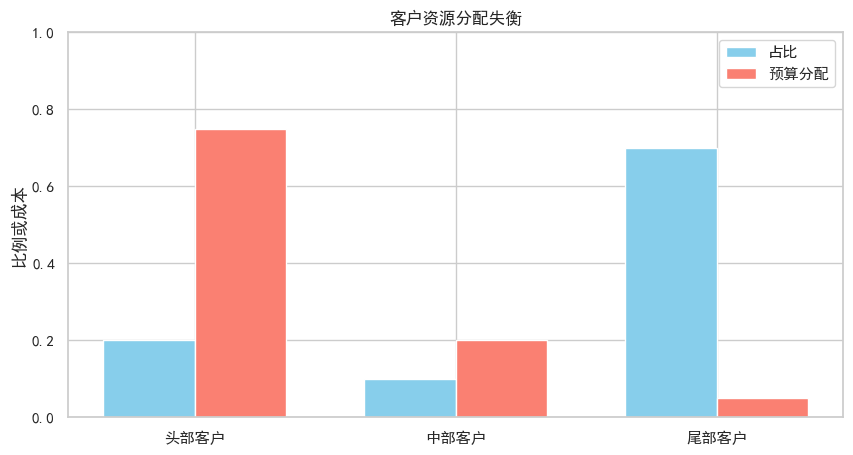

In [10]:
import matplotlib.pyplot as plt

# 客户分层数据
客户层次 = ['头部客户', '中部客户', '尾部客户']
占比 = [0.20, 0.10, 0.70]
预算分配 = [0.75, 0.20, 0.05]
人均获客成本 = [85, 44, 11]
潜在价值开发率 = [0.92, 0.65, 0.28]

# 创建占比与预算分配的对比条形图
plt.figure(figsize=(10, 5))

# 设置条形的宽度
width = 0.35

# 绘制占比
plt.bar([x - width/2 for x in range(len(客户层次))], 占比, width, label='占比', color='skyblue')
# 绘制预算分配
plt.bar([x + width/2 for x in range(len(客户层次))], 预算分配, width, label='预算分配', color='salmon')

# 设置图表标题和标签
plt.title('客户资源分配失衡')
plt.xticks(range(len(客户层次)), 客户层次)
plt.ylabel('比例或成本')
plt.ylim(0, 1)  # 设置y轴范围为0到1以适应比例展示
plt.legend()

# 显示图表
plt.show()
